# Lecture 2：Jupyter Notebook / Lab 学习与练习

这份 Notebook 将讲义内容整理为“概念 → 代码 → 结果解析 → 练习”。请从上到下逐格运行。

- 原始讲义：[Lec 2.docx](Lec%202.docx)
- 课程演示：[demo.ipynb](demo.ipynb)
- 运行当前单元格并移动到下一格：`Shift + Enter`
- 只运行当前单元格：`Ctrl + Enter`

> 本 Notebook 中出现的 `%`、`%%` 和 `!` 是需要你主动运行的教学示例。不要运行来源不明 Notebook 中的 Shell 命令。


## 学习目标

完成后，你应该能够：

1. 区分 Notebook 文档、代码单元格和 Kernel。
2. 解释为什么单元格的执行顺序会影响结果。
3. 使用 `%run`、`%load`、`%timeit`、`%who`、`%whos`、`%history` 和 `%%html`。
4. 使用 `?`、`??` 和 Tab 补全探索 Python 对象。
5. 正确处理工作目录、Shell 命令及跨平台差异。
6. 理解多个 Notebook、Kernel 与 Console 之间的状态关系。
7. 用 Markdown、代码与图表组织一个可复现的实验。


## 1. 最重要的心智模型

```text
Notebook（.ipynb）
代码 + Markdown + 已保存的输出
          │ 发送代码
          ▼
Kernel
真正运行 Python、保存变量和导入状态的进程
```

Notebook 是实验记录；Kernel 是正在工作的“大脑”。重启 Kernel 后变量会消失，但页面上旧的静态输出仍可能暂时显示。

Jupyter Notebook 侧重单个交互式文档；JupyterLab 是可以同时管理 Notebook、文本文件、Console、Terminal 等内容的工作空间。两者使用相同的 `.ipynb` 文档格式。


### 检查当前 Kernel 和工作目录

Kernel 选错时，常见现象是“明明安装了某个包，却无法 `import`”。下面的 `sys.executable` 会告诉你当前 Kernel 实际使用哪个 Python。


In [1]:
import sys
from pathlib import Path

print("当前 Python：", sys.executable)
print("Python 版本：", sys.version.split()[0])
print("当前目录：", Path.cwd())

当前 Python： c:\Users\Wyatt\AppData\Local\Programs\Python\Python313\python.exe
Python 版本： 3.13.5
当前目录： d:\桌面\DS2004


### 状态与执行顺序实验

先运行下一格一次。Jupyter 会自动显示单元格最后一个表达式，因此最后一行不一定需要 `print()`。


In [2]:
a = 19
b = 22
total = a + b

total  # 预期：41

41

In [3]:
total += 1
total

42

**观察：**

1. 第一次运行上一格得到 `42`。
2. 再运行一次得到 `43`。
3. `In [数字]` 表示真正的执行顺序，而不是单元格位置。
4. 选择 **Kernel → Restart Kernel**，然后只运行 `total += 1` 那格，会出现 `NameError`，因为新 Kernel 中还没有 `total`。

> 做完这个故障实验后，请重新从上到下运行本节，让后面的练习拥有正确状态。分享 Notebook 前应执行 **Restart Kernel and Run All Cells**；只有这样仍能成功，结果才算可复现。


### 三种常见单元格

| 类型 | 用途 | `Shift + Enter` 的效果 |
|---|---|---|
| Code | Python、Magic、Shell | 发送给 Kernel 执行 |
| Markdown | 标题、解释、公式、链接 | 渲染为排版内容 |
| Raw | 保留原始文本，常用于特殊导出 | 不执行，也不按 Markdown 渲染 |

下面这个单元格本身就是 Markdown 示例。双击它可以查看源码，再按 `Shift + Enter` 恢复渲染。


# DS2004 实验记录

## 本节结果

- **粗体**与 *斜体*
- 行内代码：`total = a + b`
- 行内公式：$y=x^2$
- [CityU](https://www.cityu.edu.hk)

> 结论：Notebook 能把代码、解释、公式和输出放在一起。

---


## 2. Magic Commands

Magic 属于 IPython/Jupyter，不是标准 Python 语法。复制到普通 `.py` 文件中可能报错。

- `%命令`：line magic，控制当前一行。
- `%%命令`：cell magic，控制整个单元格，必须写在第一行。

先看看当前 Kernel 提供了哪些 Magic：


In [4]:
%lsmagic

'Available line magics:\n%alias  %alias_magic  %autoawait  %autocall  %automagic  %autosave  %bookmark  %cd  %clear  %cls  %code_wrap  %colors  %conda  %config  %connect_info  %copy  %ddir  %debug  %dhist  %dirs  %doctest_mode  %echo  %ed  %edit  %env  %gui  %hist  %history  %killbgscripts  %ldir  %less  %load  %load_ext  %loadpy  %logoff  %logon  %logstart  %logstate  %logstop  %ls  %lsmagic  %macro  %magic  %mamba  %matplotlib  %micromamba  %mkdir  %more  %notebook  %page  %pastebin  %pdb  %pdef  %pdoc  %pfile  %pinfo  %pinfo2  %pip  %popd  %pprint  %precision  %prun  %psearch  %psource  %pushd  %pwd  %pycat  %pylab  %qtconsole  %quickref  %recall  %rehashx  %reload_ext  %ren  %rep  %rerun  %reset  %reset_selective  %rmdir  %run  %save  %sc  %set_env  %store  %subshell  %sx  %system  %tb  %time  %timeit  %unalias  %unload_ext  %uv  %who  %who_ls  %whos  %xdel  %xmode\n\nAvailable cell magics:\n%%!  %%HTML  %%SVG  %%bash  %%capture  %%cmd  %%code_wrap  %%debug  %%file  %%html  %%javas

### `%run`：执行脚本；`%load`：载入源码

为了让练习自包含，下一格使用额外的 `%%writefile` Magic，在当前目录创建 `lec2_hello_demo.py`。它只用于本节练习。


In [5]:
%%writefile lec2_hello_demo.py
course = "DS2004"

def greet(name):
    return f"你好，{name}！欢迎学习 {course}"

Overwriting lec2_hello_demo.py


In [6]:
%run lec2_hello_demo.py

print(course)
print(greet("Ada"))

DS2004
你好，Ada！欢迎学习 DS2004


预期输出：

```text
DS2004
你好，Ada！欢迎学习 DS2004
```

`%run` 像独立程序一样运行脚本；完成后，脚本定义的变量和函数会进入 Notebook 的交互命名空间。

下面的 `%load` 第一次运行时会把文件源码载入当前输入单元格，但不等于已经执行该源码。观察单元格变化后，再运行一次载入的代码。


In [32]:
# %load lec2_hello_demo.py
course = "DS2004"

def greet(name):
    return f"你好，{name}！欢迎学习 {course}"


### `%timeit`：性能测量

它会自动选择循环次数并重复测量。输出随电脑、Python 版本和系统负载变化，讲义中的具体微秒数不是固定答案。


In [8]:
%timeit [x * x for x in range(1000)]

20.8 μs ± 530 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [9]:
%%timeit
squares = []
for x in range(1000):
    squares.append(x * x)

22.9 μs ± 229 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


第一格是 line magic；第二格是 cell magic。比较性能前，要先确认两段代码完成相同任务。输出中的 `±` 表示多轮测量结果存在波动。


### `%who`、`%whos` 与 `%history`


In [10]:
number = 10
items = [1, 2, 3]
label = "data"

In [11]:
%who

Path	 a	 b	 course	 greet	 items	 label	 number	 sys	 
total	 


In [12]:
%whos

Variable   Type        Data/Info
--------------------------------
Path       type        <class 'pathlib._local.Path'>
a          int         19
b          int         22
course     str         DS2004
greet      function    <function greet at 0x00000206611D8540>
items      list        n=3
label      str         data
number     int         10
sys        module      <module 'sys' (built-in)>
total      int         42


In [13]:
%history -n -l 5

   8: %timeit [x * x for x in range(1000)]
   9:
%%timeit
squares = []
for x in range(1000):
    squares.append(x * x)
  10:
number = 10
items = [1, 2, 3]
label = "data"
  11: %who
  12: %whos


- `%who`：快速看变量名。
- `%whos`：查看变量类型、值或长度摘要。
- `%history`：查看输入历史；`-n` 显示序号，`-l 5` 取最近五条。


### `%%html`：富媒体输出

使用官方小写名称 `%%html`，并确保它位于单元格第一行。这个例子不依赖外部图片。


In [14]:
%%html
<div style="padding:12px; border-left:5px solid #2563eb; background:#eff6ff">
  <strong>Jupyter 富输出</strong>
  <p>代码、解释和 HTML 可以出现在同一个 Notebook 中。</p>
</div>

## 3. `?`、`??` 与 Tab 补全

`?` 主要显示类型、函数签名和文档字符串；`??` 进一步尝试显示源码。这些是 IPython 语法，在普通 `.py` 文件中应使用 `help(...)` 或 `inspect` 模块。


In [15]:
import math
math.sqrt?

Signature: math.sqrt(x, /)
Docstring: Return the square root of x.
Type:      builtin_function_or_method

你会看到类似 `Signature: math.sqrt(x, /)`。其中 `/` 表示前面的 `x` 是**仅限位置参数**，不能写成关键字参数。


In [16]:
print(math.sqrt(9))  # 正确：3.0

try:
    math.sqrt(x=9)   # 错误示范，但用 try 捕获，所以不会中断 Run All
except TypeError as error:
    print(type(error).__name__ + ":", error)

3.0
TypeError: math.sqrt() takes no keyword arguments


In [17]:
math.sqrt??

Signature: math.sqrt(x, /)
Docstring: Return the square root of x.
Type:      builtin_function_or_method

`math.sqrt` 由 C 实现，`??` 通常无法展示有意义的 Python 源码。自己写的函数则不同：


In [18]:
def my_func(x):
    """返回 x 加 1。"""
    return x + 1

print(my_func(10))

11


In [19]:
my_func?

Signature: my_func(x)
Docstring: 返回 x 加 1。
File:      ~\appdata\local\temp\ipykernel_39560\829777450.py
Type:      function

In [20]:
my_func??

Signature: my_func(x)
Source:   
def my_func(x):
    """返回 x 加 1。"""
    return x + 1
File:      ~\appdata\local\temp\ipykernel_39560\829777450.py
Type:      function

### Tab 补全练习

1. 先运行下一格定义 `text`。
2. 在新的空代码格输入 `text.`，先不要运行。
3. 光标放在句点后按 `Tab`，选择 `upper`。
4. 加上括号并运行 `text.upper()`。

Tab 还可以补全变量名、对象属性、模块名和文件路径。它既能探索陌生 API，也能减少拼写错误。


In [21]:
text = "jupyter"
text.upper()  # 先运行一次；然后删掉 upper()，亲手用 Tab 补回来

'JUPYTER'

## 4. 工作目录与 Shell 命令

相对路径从当前工作目录开始解析。优先使用下面的跨平台 Python 写法：


In [22]:
from pathlib import Path

current_dir = Path.cwd()
print("当前目录：", current_dir)
print("目录内容：")
for item in sorted(current_dir.iterdir(), key=lambda path: path.name.lower()):
    print(" -", item.name)

当前目录： d:\桌面\DS2004
目录内容：
 - .kilo
 - lec2_hello_demo.py
 - Lec2_Jupyter_学习与练习.ipynb
 - WEEK2


In [23]:
%pwd

'd:\\桌面\\DS2004'

以 `!` 开头的内容会交给操作系统 Shell，而不是 Python：

```text
Windows：       !cd       和 !dir
macOS/Linux：   !pwd      和 !ls -la
```

讲义先讲 Windows，却使用了偏 Unix 的 `!pwd`、`!ls -l`；因此不能假设这些命令处处通用。

另外，`!cd some_folder` 在子进程中执行，通常不会永久改变 Notebook 的目录。需要改变 Kernel 的当前目录时，应使用 `%cd some_folder`。


## 5. Notebook、Kernel 与 Console

下面进行一个需要 JupyterLab 界面配合的实验。先运行下一格：


In [24]:
shared_value = 42
print("当前 Notebook 已定义 shared_value")

当前 Notebook 已定义 shared_value


操作步骤：

1. 右击当前 Notebook，选择 **New Console for Notebook**。
2. 在 Console 中输入 `shared_value`，应得到 `42`，因为 Console 与当前 Notebook 共用 Kernel。
3. 新建一个使用新 Kernel 的 Notebook，在那里输入 `shared_value`，通常得到 `NameError`。
4. 即使两个页面都显示 `Python 3`，它们也可能只是使用相同环境类型，而不是共享同一个进程。
5. 关闭 Notebook 标签页不一定会关闭 Kernel；可以在左侧 **Running** 面板查看和关闭。


## 6. 可视化输出

讲义的 `demo.ipynb` 使用 Matplotlib 绘图。下面的代码在缺少 Matplotlib 时会给出提示，而不会中断整份 Notebook。


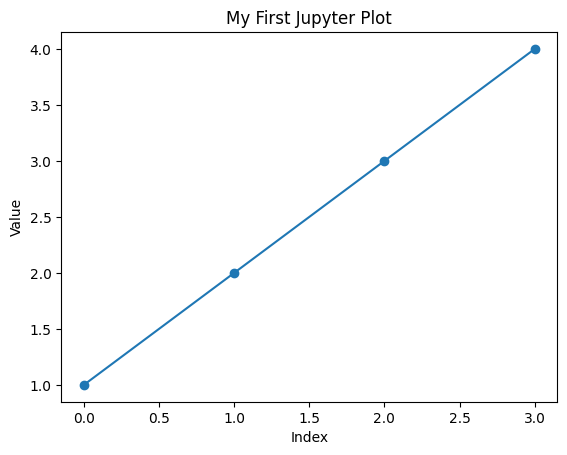

In [25]:
try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    print("当前 Kernel 未安装 matplotlib，可暂时跳过本练习。")
else:
    plt.plot([1, 2, 3, 4], marker="o")
    plt.title("My First Jupyter Plot")
    plt.xlabel("Index")
    plt.ylabel("Value")
    plt.show()

当 `plt.plot(...)` 是单元格最后一个表达式时，Jupyter 可能同时显示 `Line2D` 对象描述和图形。显式调用 `plt.show()` 可以让意图更清楚。


## 7. 原讲义与 `demo.ipynb` 的易错点

| 原内容 | 正确理解或改进 |
|---|---|
| `Juypter` | 正确拼写为 `Jupyter` |
| `impot math` | 应为 `import math` |
| `sum = a + b` | 建议写 `total`，否则会遮蔽 Python 内置的 `sum()` |
| `%%HTML` | 使用官方名称 `%%html` |
| Windows 示例使用 `!ls -l` | 改用 `!dir`，或使用跨平台的 `pathlib` |
| 标题文字放在 Raw 单元格 | Raw 不按 Markdown 渲染，应切换为 Markdown |
| `print(d)` | 必须先在共享 Kernel 的 Console 中定义 `d` |
| `python_anaconda.jpg` | 当前目录没有这张图片，原 Markdown/HTML 图片示例无法显示 |

下面观察为什么不推荐把变量命名为 `sum`：


In [26]:
sum = 41

try:
    sum([1, 2, 3])
except TypeError as error:
    print(type(error).__name__ + ":", error)

del sum
print("恢复内置 sum() 后：", sum([1, 2, 3]))

TypeError: 'int' object is not callable
恢复内置 sum() 后： 6


## 8. 最终掌握练习

先阅读要求，尽量自己在一个新单元格重写，然后再运行参考实现：

1. 创建成绩列表。
2. 写一个函数，返回平均分和不低于 70 分的成绩。
3. 添加 docstring。
4. 用断言检查结果。
5. 再用 `?`、`%timeit`、`%whos` 和 `%history` 检查它。


In [27]:
scores = [72, 88, 91, 65, 84]

def summarize(values):
    """返回平均分和不低于 70 分的成绩。"""
    average = sum(values) / len(values)
    passed = [value for value in values if value >= 70]
    return average, passed

average, passed = summarize(scores)
print(f"平均分：{average:.1f}")
print("达标成绩：", passed)

平均分：80.0
达标成绩： [72, 88, 91, 84]


In [28]:
assert average == 80
assert passed == [72, 88, 91, 84]
print("✓ 结果检查通过")

✓ 结果检查通过


In [29]:
summarize?

Signature: summarize(values)
Docstring: 返回平均分和不低于 70 分的成绩。
File:      ~\appdata\local\temp\ipykernel_39560\1605635108.py
Type:      function

In [30]:
%timeit summarize(scores)

200 ns ± 1.92 ns per loop (mean ± std. dev. of 7 runs, 10,000,000 loops each)


In [31]:
%whos
%history -n -l 5

Variable       Type           Data/Info
---------------------------------------
Path           type           <class 'pathlib._local.Path'>
a              int            19
average        float          80.0
b              int            22
course         str            DS2004
current_dir    WindowsPath    d:\桌面\DS2004
greet          function       <function greet at 0x00000206611D8540>
item           WindowsPath    d:\桌面\DS2004\WEEK2
items          list           n=3
label          str            data
math           module         <module 'math' (built-in)>
my_func        function       <function my_func at 0x00000206611D8AE0>
number         int            10
passed         list           n=4
plt            module         <module 'matplotlib.pyplo<...>\\matplotlib\\pyplot.py'>
scores         list           n=5
shared_value   int            42
summarize      function       <function summarize at 0x000002065FF02A20>
sys            module         <module 'sys' (built-in)>
text           

## 完成检查

现在选择 **Kernel → Restart Kernel and Run All Cells**。如果整份 Notebook 能从头执行到 `✓ 结果检查通过`，说明你已经掌握 Lecture 2 的核心内容。

你应该能回答：

- 为什么单元格位置不代表执行顺序？
- `%run` 与 `%load` 的区别是什么？
- 为什么 `%timeit` 的结果每台电脑不同？
- `?` 与 `??` 分别解决什么问题？
- 为什么 `!ls -l` 在 Windows 上可能失败？
- 为什么新 Notebook 中看不到另一个 Notebook 的变量，而附加 Console 通常可以？

### 官方参考

- [JupyterLab Notebooks](https://jupyterlab.readthedocs.io/en/stable/user/notebook.html)
- [JupyterLab Documents and Kernels](https://jupyterlab.readthedocs.io/en/stable/user/documents_kernels.html)
- [IPython Magic Commands](https://ipython.readthedocs.io/en/stable/interactive/magics.html)
- [IPython Interactive Tutorial](https://ipython.readthedocs.io/en/stable/interactive/tutorial.html)
